# Graph 1 ABCDEF

Simple matplotlib plots from `runner_May1st_processed`.

In [146]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

plt.rcParams["figure.dpi"] = 160
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 11
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["legend.fontsize"] = 10

In [147]:
processed_root = Path("/Users/patange/Documents/Argonne/QEC/log/runner_May1st_processed")

rows = []

for sweep_dir in sorted(processed_root.iterdir()):
    if not sweep_dir.is_dir():
        continue

    for path in sorted(sweep_dir.iterdir()):
        if not path.is_file():
            continue

        text = path.read_text().strip()
        latency_ps, fidelity_corrected, rows_processed = [part.strip() for part in text.split(",")]

        name = path.name
        nodes = int(re.search(r"line_(\d+)_2G", name).group(1))

        if sweep_dir.name == "graph_initialization_fidelity_sweep":
            sweep_value = float(re.search(r"(?:^|,)prep=([^,]+)", name).group(1))
        elif sweep_dir.name == "graph_measurement_fidelity_sweep":
            sweep_value = float(re.search(r"(?:^|,)meas=([^,]+)", name).group(1))
        elif sweep_dir.name == "graph_physical_bell_pair_fidelity_sweep":
            sweep_value = float(re.search(r"(?:^|,)physbell=([^,]+)", name).group(1))
        elif sweep_dir.name == "one_qubit_gate_sweep":
            sweep_value = float(re.search(r"(?:^|,)gate=([^,]+)", name).group(1))
        elif sweep_dir.name == "t2_sweep":
            sweep_value = float(re.search(r"(?:^|,)T2=([^,]+)", name).group(1))
        elif sweep_dir.name == "two_qubit_gate_sweep":
            sweep_value = float(re.search(r"(?:^|,)twoq=([^,]+)", name).group(1))
        else:
            continue

        rows.append(
            {
                "sweep_name": sweep_dir.name,
                "nodes": nodes,
                "sweep_value": sweep_value,
                "latency_ps": float(latency_ps),
                "fidelity_corrected": float(fidelity_corrected),
                "rows_processed": int(rows_processed),
                "log_name": name,
            }
        )

df = pd.DataFrame(rows).sort_values(["sweep_name", "nodes", "sweep_value"]).reset_index(drop=True)
df.head()

,sweep_name,nodes,sweep_value,latency_ps,fidelity_corrected,rows_processed,log_name
0,graph_initialization_fidelity_sweep,2,0.990,3.024484e+09,0.999097,90782,"line_2_2G,code=[[7,1,3]],dist=0.001,gate=1.0,t..."
1,graph_initialization_fidelity_sweep,2,0.991,3.039368e+09,0.999281,89010,"line_2_2G,code=[[7,1,3]],dist=0.001,gate=1.0,t..."
2,graph_initialization_fidelity_sweep,2,0.992,3.036188e+09,0.999397,89544,"line_2_2G,code=[[7,1,3]],dist=0.001,gate=1.0,t..."
3,graph_initialization_fidelity_sweep,2,0.993,3.037695e+09,0.999565,89578,"line_2_2G,code=[[7,1,3]],dist=0.001,gate=1.0,t..."
4,graph_initialization_fidelity_sweep,2,0.994,3.031432e+09,0.999610,89676,"line_2_2G,code=[[7,1,3]],dist=0.001,gate=1.0,t..."


In [148]:
init_df = df[df["sweep_name"] == "graph_initialization_fidelity_sweep"].copy()
meas_df = df[df["sweep_name"] == "graph_measurement_fidelity_sweep"].copy()
bell_df = df[df["sweep_name"] == "graph_physical_bell_pair_fidelity_sweep"].copy()
oneq_df = df[df["sweep_name"] == "one_qubit_gate_sweep"].copy()
t2_df = df[df["sweep_name"] == "t2_sweep"].copy()
twoq_df = df[df["sweep_name"] == "two_qubit_gate_sweep"].copy()

node_colors = {2: "tab:blue", 3: "tab:orange", 6: "tab:green"}
node_markers = {2: "o", 3: "s", 6: "^"}

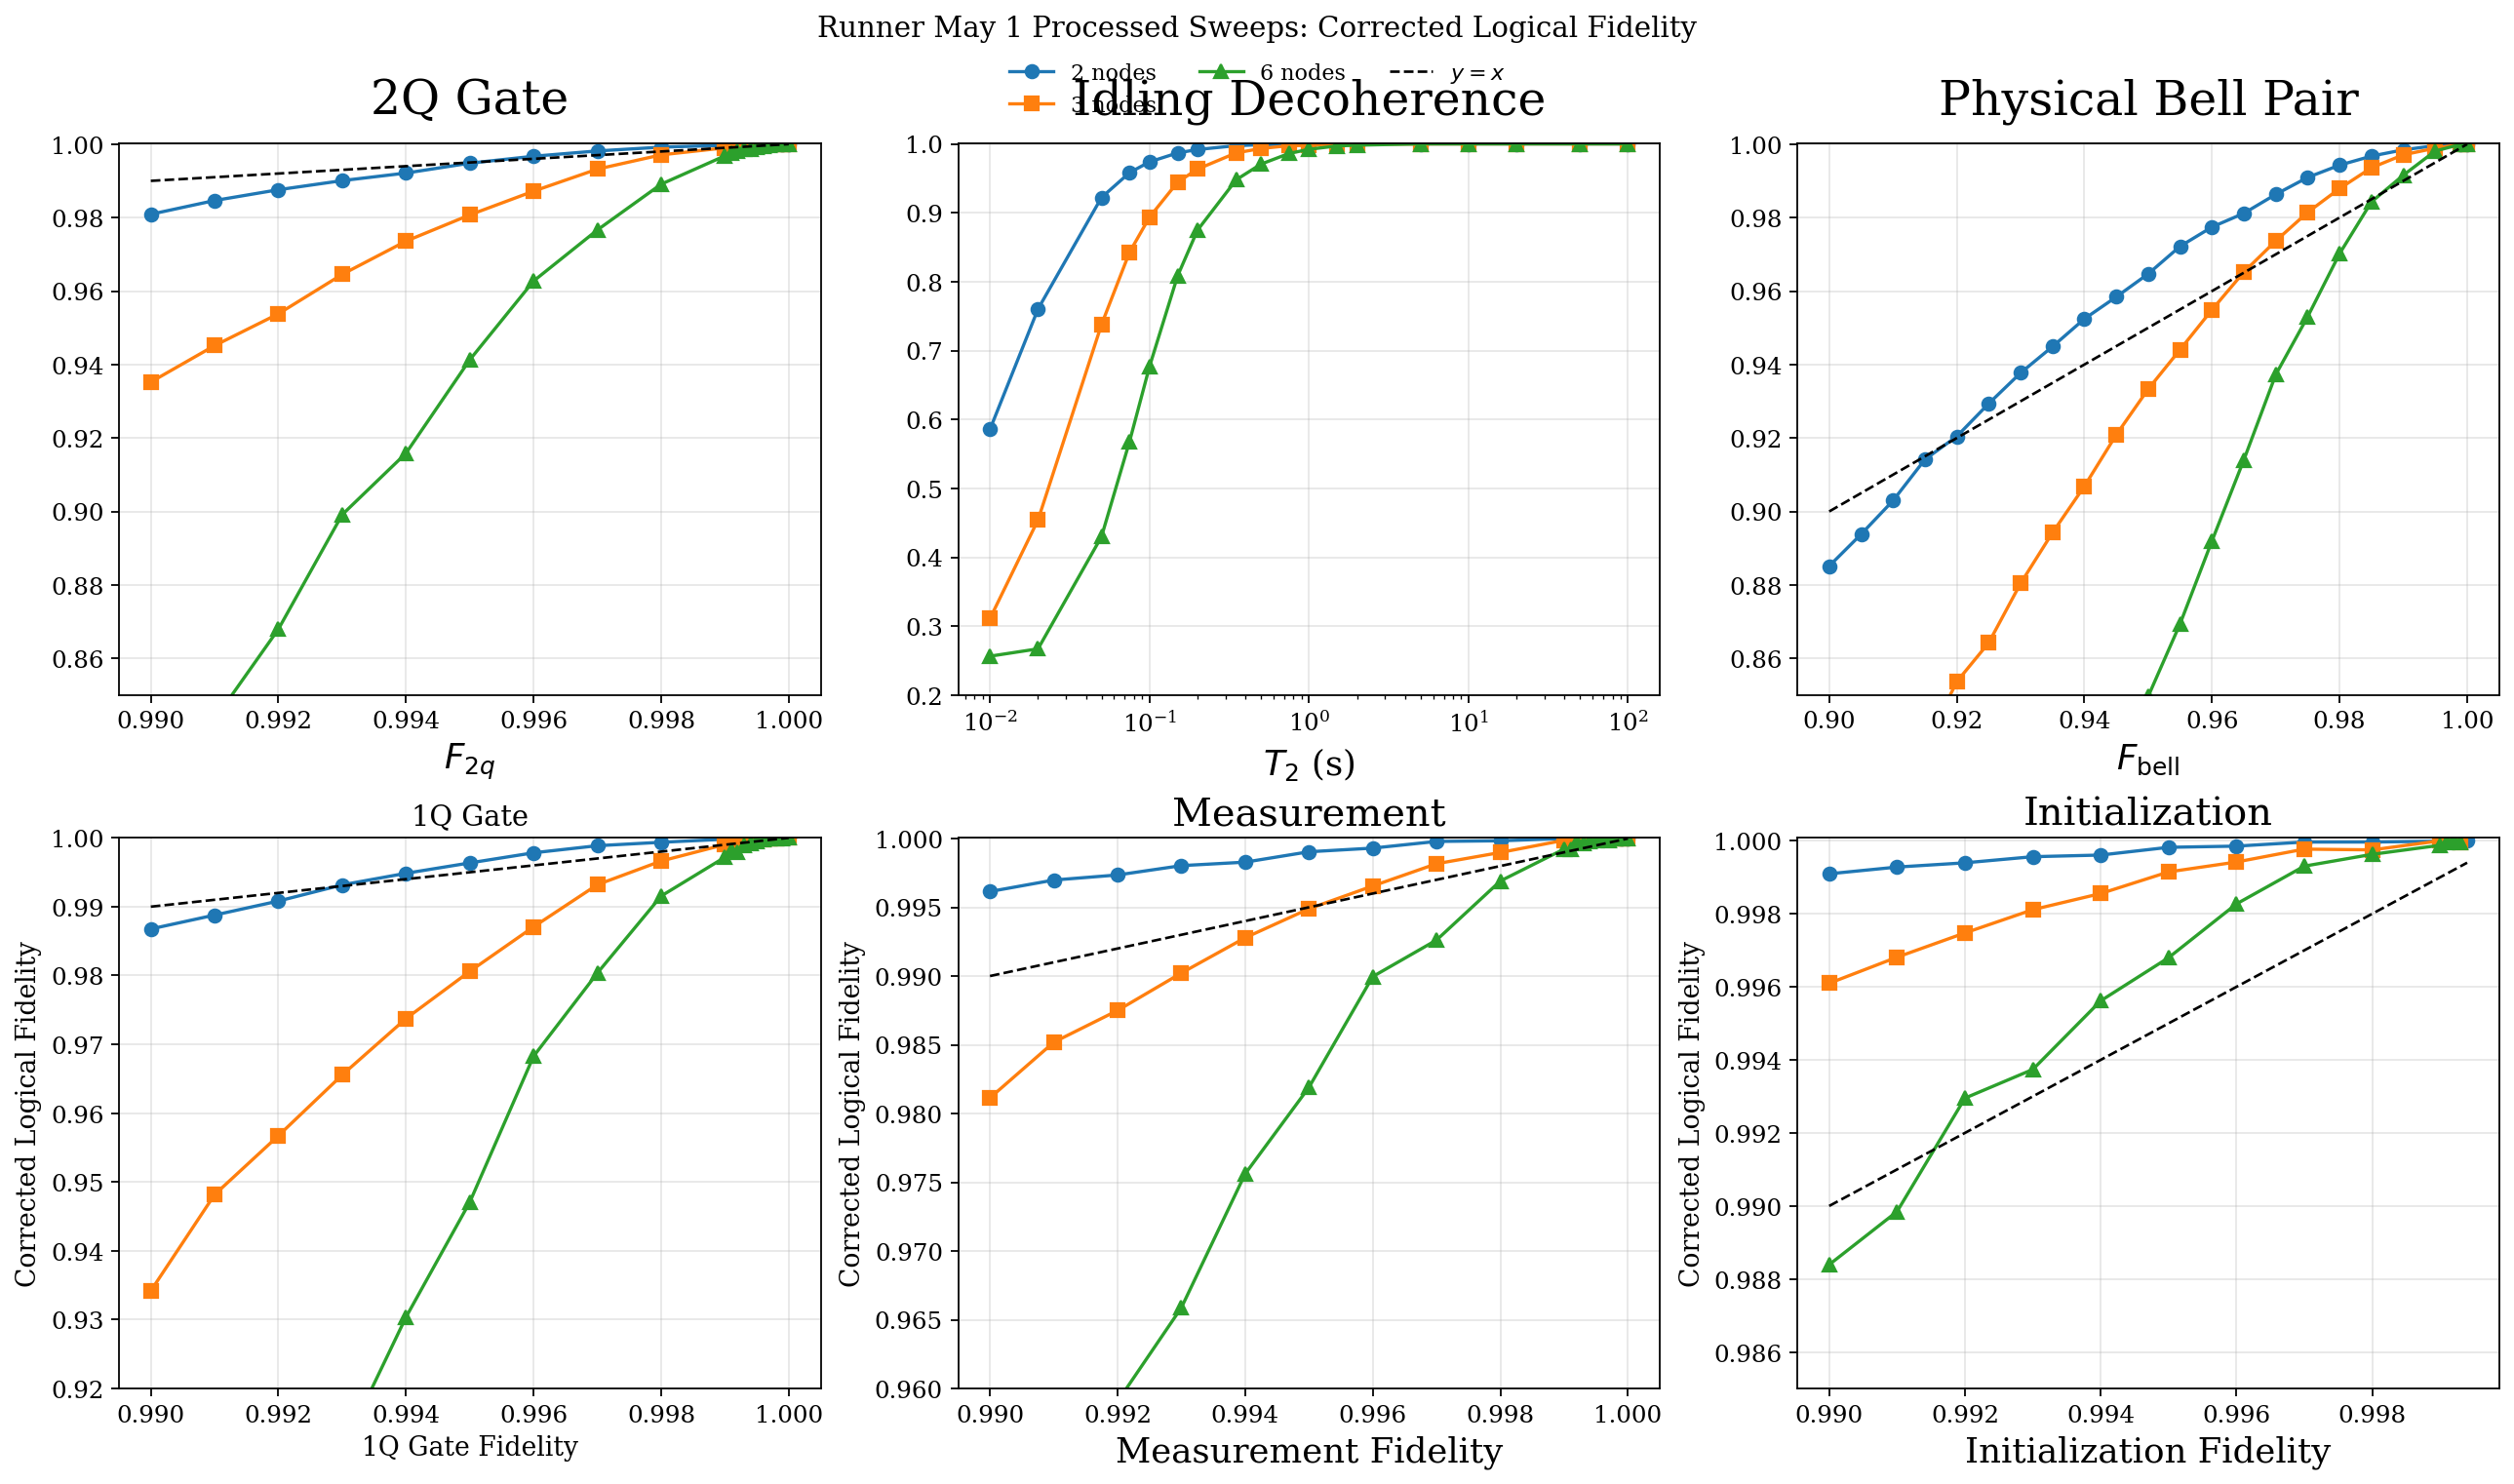

In [149]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)

for nodes in sorted(twoq_df["nodes"].unique()):
    d = twoq_df[twoq_df["nodes"] == nodes]
    axes[0, 0].plot(d["sweep_value"], d["fidelity_corrected"], color=node_colors[nodes], marker=node_markers[nodes], label=f"{nodes} nodes")
xline = np.linspace(twoq_df["sweep_value"].min(), twoq_df["sweep_value"].max(), 200)
axes[0, 0].plot(xline, xline, linestyle="--", color="black", linewidth=1.2, label=r"$\boldsymbol{y=x}$")
axes[0, 0].set_title("2Q Gate", fontsize=22, pad=14)
axes[0, 0].set_xlabel(r"$F_{2q}$", fontsize=16)
axes[0, 0].set_ylim(0.85, 1.0001)
axes[0, 0].grid(True, alpha=0.3)

for nodes in sorted(t2_df["nodes"].unique()):
    d = t2_df[t2_df["nodes"] == nodes]
    axes[0, 1].plot(d["sweep_value"], d["fidelity_corrected"], color=node_colors[nodes], marker=node_markers[nodes], label=f"{nodes} nodes")
xline = np.linspace(t2_df["sweep_value"].min(), t2_df["sweep_value"].max(), 200)
# axes[0, 1].plot(xline, xline, linestyle="--", color="black", linewidth=1.2, label=r"$\boldsymbol{y=x}$")
axes[0, 1].set_title("Idling Decoherence", fontsize=22, pad=14)
axes[0, 1].set_xlabel(r"$T_2$ (s)", fontsize=16)
axes[0, 1].set_xscale("log")
axes[0, 1].set_ylim(0.2, 1.0001)
axes[0, 1].grid(True, alpha=0.3)

for nodes in sorted(bell_df["nodes"].unique()):
    d = bell_df[bell_df["nodes"] == nodes]
    axes[0, 2].plot(d["sweep_value"], d["fidelity_corrected"], color=node_colors[nodes], marker=node_markers[nodes], label=f"{nodes} nodes")
xline = np.linspace(bell_df["sweep_value"].min(), bell_df["sweep_value"].max(), 200)
axes[0, 2].plot(xline, xline, linestyle="--", color="black", linewidth=1.2, label=r"$\boldsymbol{y=x}$")
axes[0, 2].set_title("Physical Bell Pair", fontsize=22, pad=14)
axes[0, 2].set_xlabel(r"$F_{\mathrm{bell}}$", fontsize=16)
axes[0, 2].set_ylim(0.85, 1.0001)
axes[0, 2].grid(True, alpha=0.3)

for nodes in sorted(oneq_df["nodes"].unique()):
    d = oneq_df[oneq_df["nodes"] == nodes]
    axes[1, 0].plot(d["sweep_value"], d["fidelity_corrected"], color=node_colors[nodes], marker=node_markers[nodes], label=f"{nodes} nodes")
xline = np.linspace(oneq_df["sweep_value"].min(), oneq_df["sweep_value"].max(), 200)
axes[1, 0].plot(xline, xline, linestyle="--", color="black", linewidth=1.2, label=r"$\boldsymbol{y=x}$")
axes[1, 0].set_title("1Q Gate")
axes[1, 0].set_xlabel("1Q Gate Fidelity")
axes[1, 0].set_ylabel("Corrected Logical Fidelity")
axes[1, 0].set_ylim(0.92, 1.0001)
axes[1, 0].grid(True, alpha=0.3)

for nodes in sorted(meas_df["nodes"].unique()):
    d = meas_df[meas_df["nodes"] == nodes]
    axes[1, 1].plot(d["sweep_value"], d["fidelity_corrected"], color=node_colors[nodes], marker=node_markers[nodes], label=f"{nodes} nodes")
xline = np.linspace(meas_df["sweep_value"].min(), meas_df["sweep_value"].max(), 200)
axes[1, 1].plot(xline, xline, linestyle="--", color="black", linewidth=1.2, label=r"$\boldsymbol{y=x}$")
axes[1, 1].set_title("Measurement", fontsize=18)
axes[1, 1].set_xlabel("Measurement Fidelity", fontsize=16)
axes[1, 1].set_ylabel("Corrected Logical Fidelity")
axes[1, 1].set_ylim(0.96, 1.0001)
axes[1, 1].grid(True, alpha=0.3)

for nodes in sorted(init_df["nodes"].unique()):
    d = init_df[init_df["nodes"] == nodes]
    axes[1, 2].plot(d["sweep_value"], d["fidelity_corrected"], color=node_colors[nodes], marker=node_markers[nodes], label=f"{nodes} nodes")
xline = np.linspace(init_df["sweep_value"].min(), init_df["sweep_value"].max(), 200)
axes[1, 2].plot(xline, xline, linestyle="--", color="black", linewidth=1.2, label=r"$\boldsymbol{y=x}$")
axes[1, 2].set_title("Initialization", fontsize=18)
axes[1, 2].set_xlabel("Initialization Fidelity", fontsize=16)
axes[1, 2].set_ylabel("Corrected Logical Fidelity")
axes[1, 2].set_ylim(0.985, 1.0001)
axes[1, 2].grid(True, alpha=0.3)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Runner May 1 Processed Sweeps: Corrected Logical Fidelity", y=1.04)

fig.savefig("/Users/patange/Documents/Argonne/QEC/plot_pngs/graph1_abcdef_fidelity_grid.png")
fig.savefig("/Users/patange/Documents/Argonne/QEC/plot_pngs/graph1_abcdef_fidelity_grid.pdf")
plt.show()

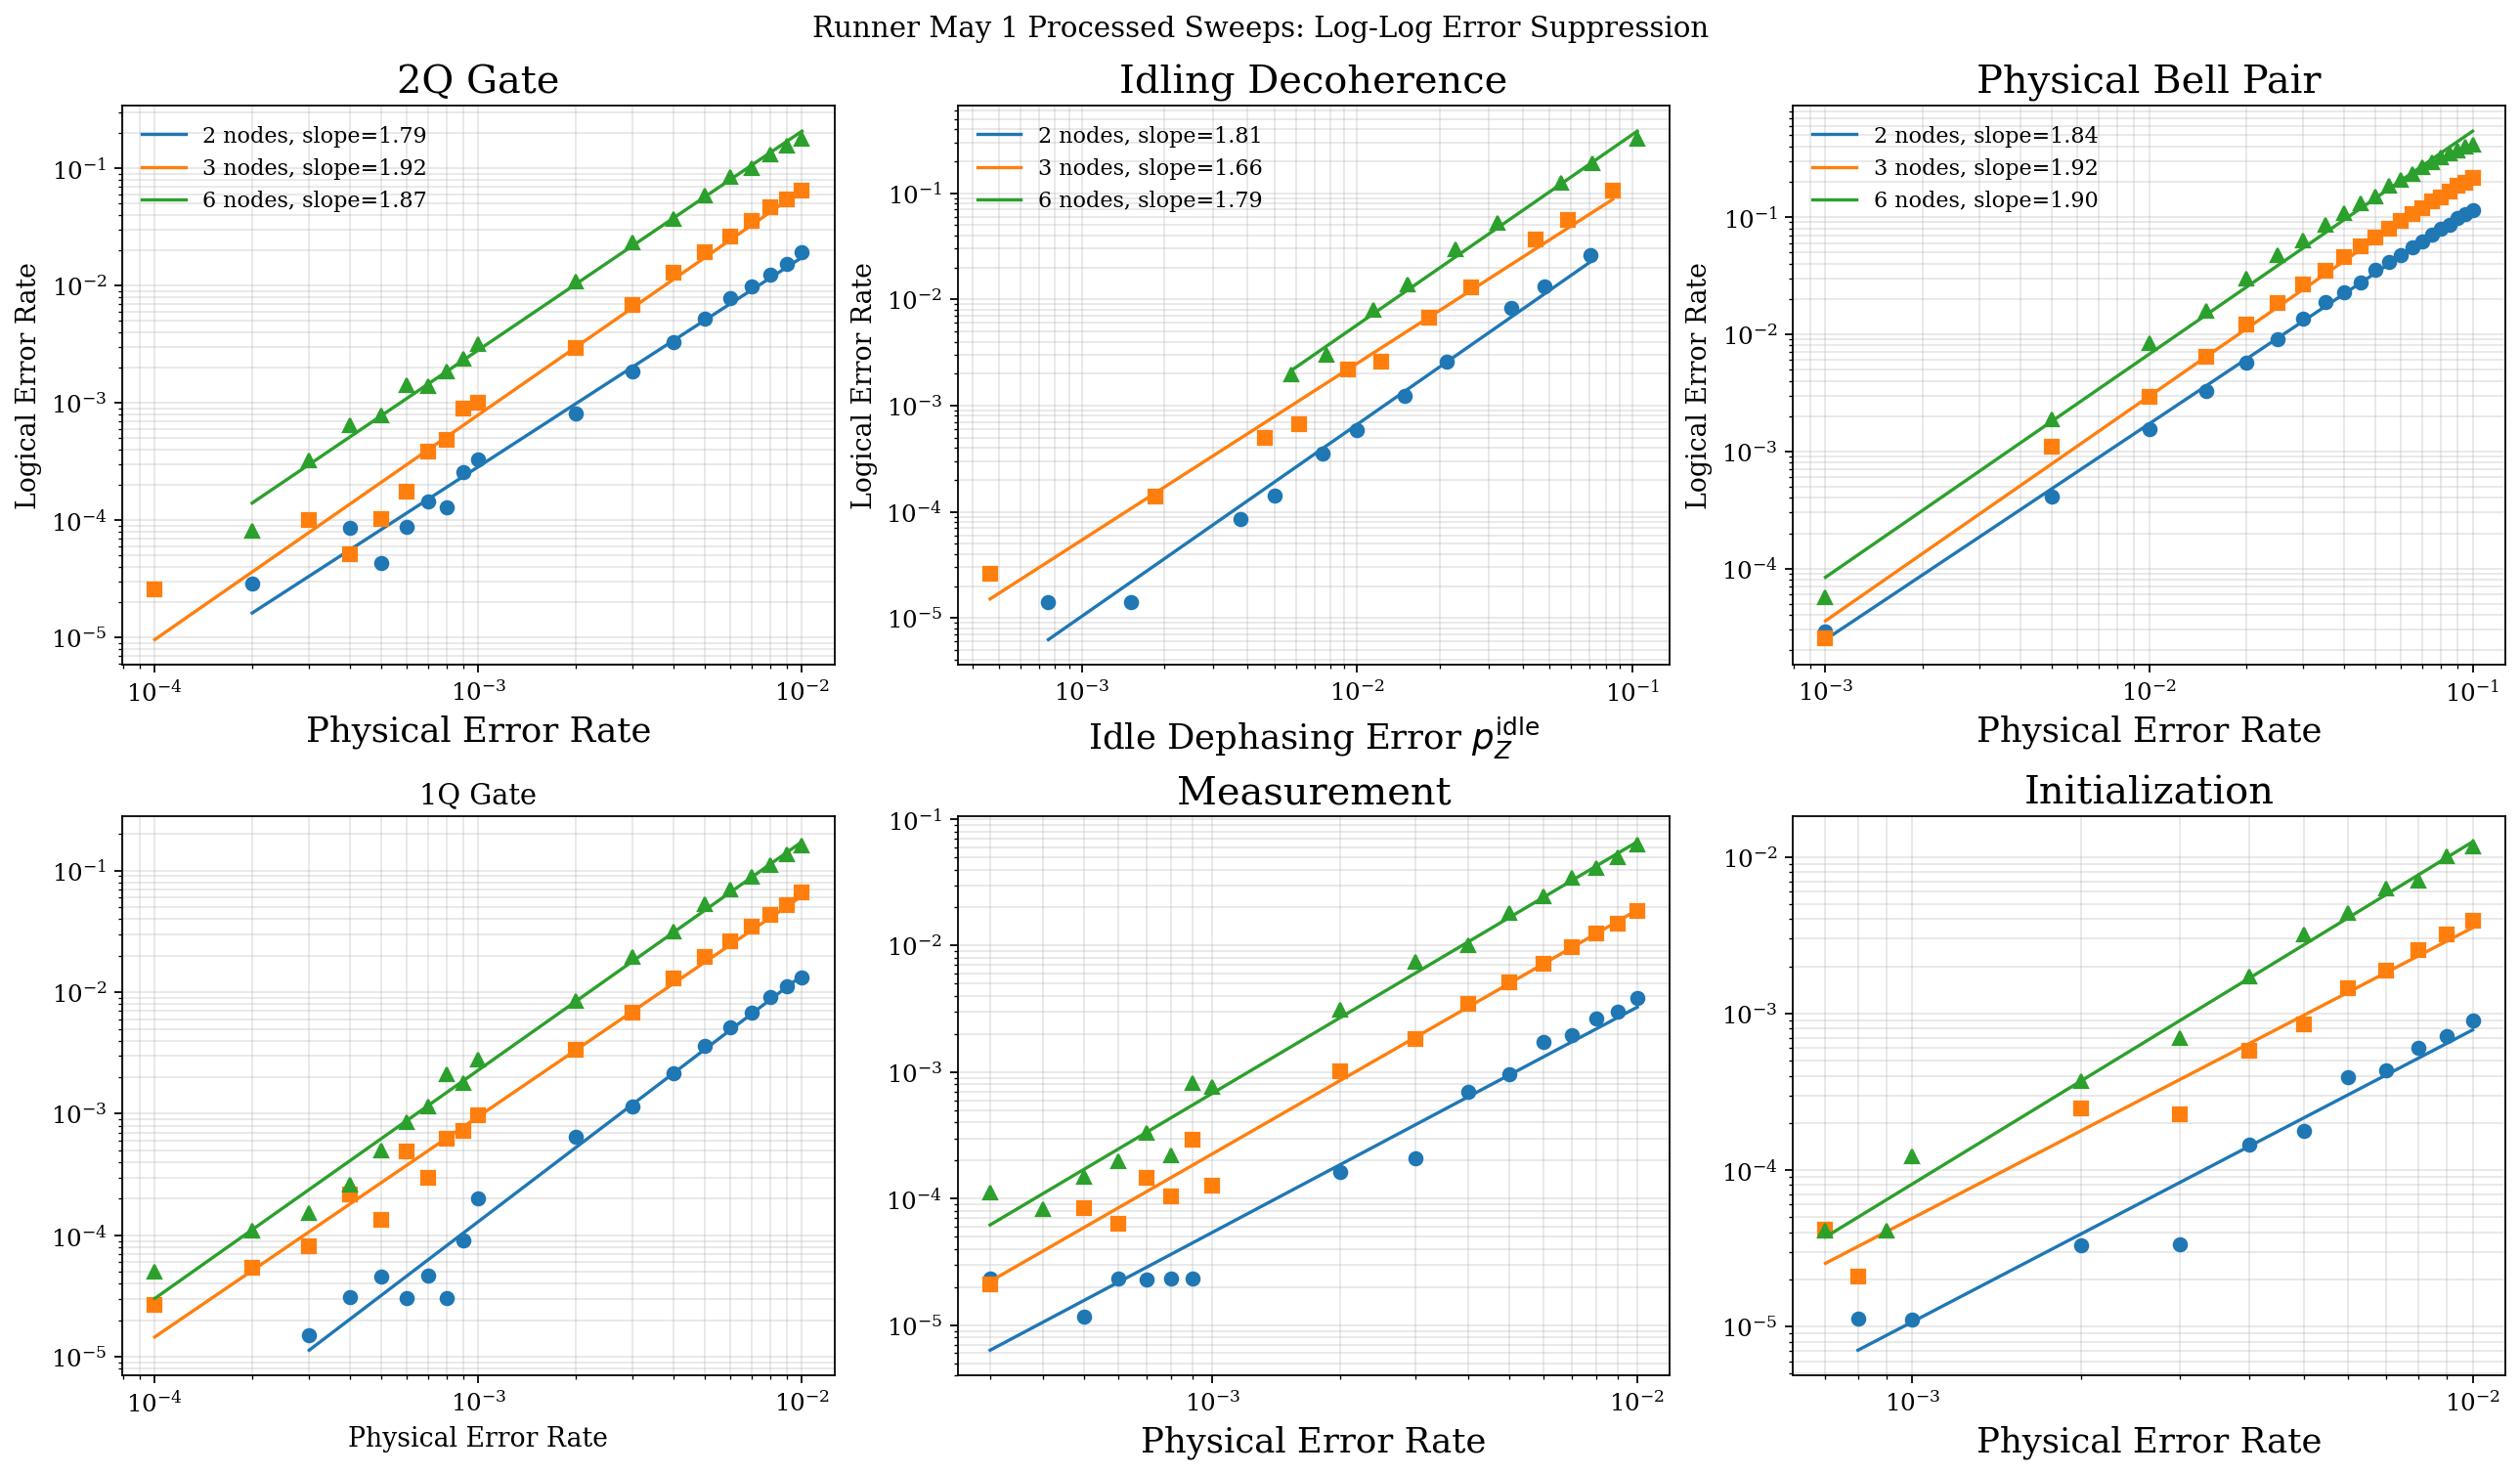

In [150]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)

for nodes in sorted(twoq_df["nodes"].unique()):
    d = twoq_df[twoq_df["nodes"] == nodes].copy()
    x = 1.0 - d["sweep_value"].to_numpy()
    y = 1.0 - d["fidelity_corrected"].to_numpy()
    mask = (x > 0.0) & (y > 0.0)
    x = x[mask]
    y = y[mask]
    axes[0, 0].plot(x, y, linestyle="", color=node_colors[nodes], marker=node_markers[nodes])
    if len(x) >= 2:
        coeffs = np.polyfit(np.log10(x), np.log10(y), 1)
        xfit = np.sort(x)
        yfit = 10 ** (coeffs[1] + coeffs[0] * np.log10(xfit))
        axes[0, 0].plot(xfit, yfit, color=node_colors[nodes], label=f"{nodes} nodes, slope={coeffs[0]:.2f}")
axes[0, 0].set_xscale("log")
axes[0, 0].set_yscale("log")
axes[0, 0].set_title("2Q Gate", fontsize=18)
axes[0, 0].set_xlabel("Physical Error Rate", fontsize=16)
axes[0, 0].set_ylabel("Logical Error Rate")
axes[0, 0].grid(True, which="both", alpha=0.3)
axes[0, 0].legend(frameon=False)

t2_fit_min = 0.1

for nodes in sorted(t2_df["nodes"].unique()):
    d = t2_df[(t2_df["nodes"] == nodes) & (t2_df["sweep_value"] >= t2_fit_min)].copy()
    idle_time_sec = d["latency_ps"].to_numpy() * 1e-12
    x = (1.0 - np.exp(-idle_time_sec / d["sweep_value"].to_numpy())) / 2.0
    y = 1.0 - d["fidelity_corrected"].to_numpy()
    mask = (x > 0.0) & (y > 0.0)
    x = x[mask]
    y = y[mask]
    axes[0, 1].plot(x, y, linestyle="", color=node_colors[nodes], marker=node_markers[nodes])
    if len(x) >= 2:
        coeffs = np.polyfit(np.log10(x), np.log10(y), 1)
        xfit = np.sort(x)
        yfit = 10 ** (coeffs[1] + coeffs[0] * np.log10(xfit))
        axes[0, 1].plot(xfit, yfit, color=node_colors[nodes], label=f"{nodes} nodes, slope={coeffs[0]:.2f}")
axes[0, 1].set_xscale("log")
axes[0, 1].set_yscale("log")
axes[0, 1].set_title("Idling Decoherence", fontsize=18)
axes[0, 1].set_xlabel(r"Idle Dephasing Error $p_Z^{\mathrm{idle}}$", fontsize=16)
axes[0, 1].set_ylabel("Logical Error Rate")
axes[0, 1].grid(True, which="both", alpha=0.3)
axes[0, 1].legend(frameon=False)

for nodes in sorted(bell_df["nodes"].unique()):
    d = bell_df[bell_df["nodes"] == nodes].copy()
    x = 1.0 - d["sweep_value"].to_numpy()
    y = 1.0 - d["fidelity_corrected"].to_numpy()
    mask = (x > 0.0) & (y > 0.0)
    x = x[mask]
    y = y[mask]
    axes[0, 2].plot(x, y, linestyle="", color=node_colors[nodes], marker=node_markers[nodes])
    if len(x) >= 2:
        coeffs = np.polyfit(np.log10(x), np.log10(y), 1)
        xfit = np.sort(x)
        yfit = 10 ** (coeffs[1] + coeffs[0] * np.log10(xfit))
        axes[0, 2].plot(xfit, yfit, color=node_colors[nodes], label=f"{nodes} nodes, slope={coeffs[0]:.2f}")
axes[0, 2].set_xscale("log")
axes[0, 2].set_yscale("log")
axes[0, 2].set_title("Physical Bell Pair", fontsize=18)
axes[0, 2].set_xlabel("Physical Error Rate", fontsize=16)
axes[0, 2].set_ylabel("Logical Error Rate")
axes[0, 2].grid(True, which="both", alpha=0.3)
axes[0, 2].legend(frameon=False)

for nodes in sorted(oneq_df["nodes"].unique()):
    d = oneq_df[oneq_df["nodes"] == nodes].copy()
    x = 1.0 - d["sweep_value"].to_numpy()
    y = 1.0 - d["fidelity_corrected"].to_numpy()
    mask = (x > 0.0) & (y > 0.0)
    x = x[mask]
    y = y[mask]
    axes[1, 0].plot(x, y, linestyle="", color=node_colors[nodes], marker=node_markers[nodes], label=f"{nodes} nodes")
    if len(x) >= 2:
        coeffs = np.polyfit(np.log10(x), np.log10(y), 1)
        xfit = np.sort(x)
        yfit = 10 ** (coeffs[1] + coeffs[0] * np.log10(xfit))
        axes[1, 0].plot(xfit, yfit, color=node_colors[nodes])
axes[1, 0].set_xscale("log")
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("1Q Gate")
axes[1, 0].set_xlabel("Physical Error Rate")
axes[1, 0].grid(True, which="both", alpha=0.3)

for nodes in sorted(meas_df["nodes"].unique()):
    d = meas_df[meas_df["nodes"] == nodes].copy()
    x = 1.0 - d["sweep_value"].to_numpy()
    y = 1.0 - d["fidelity_corrected"].to_numpy()
    mask = (x > 0.0) & (y > 0.0)
    x = x[mask]
    y = y[mask]
    axes[1, 1].plot(x, y, linestyle="", color=node_colors[nodes], marker=node_markers[nodes], label=f"{nodes} nodes")
    if len(x) >= 2:
        coeffs = np.polyfit(np.log10(x), np.log10(y), 1)
        xfit = np.sort(x)
        yfit = 10 ** (coeffs[1] + coeffs[0] * np.log10(xfit))
        axes[1, 1].plot(xfit, yfit, color=node_colors[nodes])
axes[1, 1].set_xscale("log")
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("Measurement", fontsize=18)
axes[1, 1].set_xlabel("Physical Error Rate", fontsize=16)
axes[1, 1].grid(True, which="both", alpha=0.3)

for nodes in sorted(init_df["nodes"].unique()):
    d = init_df[init_df["nodes"] == nodes].copy()
    x = 1.0 - d["sweep_value"].to_numpy()
    y = 1.0 - d["fidelity_corrected"].to_numpy()
    mask = (x > 0.0) & (y > 0.0)
    x = x[mask]
    y = y[mask]
    axes[1, 2].plot(x, y, linestyle="", color=node_colors[nodes], marker=node_markers[nodes], label=f"{nodes} nodes")
    if len(x) >= 2:
        coeffs = np.polyfit(np.log10(x), np.log10(y), 1)
        xfit = np.sort(x)
        yfit = 10 ** (coeffs[1] + coeffs[0] * np.log10(xfit))
        axes[1, 2].plot(xfit, yfit, color=node_colors[nodes])
axes[1, 2].set_xscale("log")
axes[1, 2].set_yscale("log")
axes[1, 2].set_title("Initialization", fontsize=18)
axes[1, 2].set_xlabel("Physical Error Rate", fontsize=16)
axes[1, 2].grid(True, which="both", alpha=0.3)

fig.suptitle("Runner May 1 Processed Sweeps: Log-Log Error Suppression", y=1.03)
fig.savefig("/Users/patange/Documents/Argonne/QEC/plot_pngs/graph1_abcdef_suppression_grid.png")
fig.savefig("/Users/patange/Documents/Argonne/QEC/plot_pngs/graph1_abcdef_suppression_grid.pdf")
plt.show()

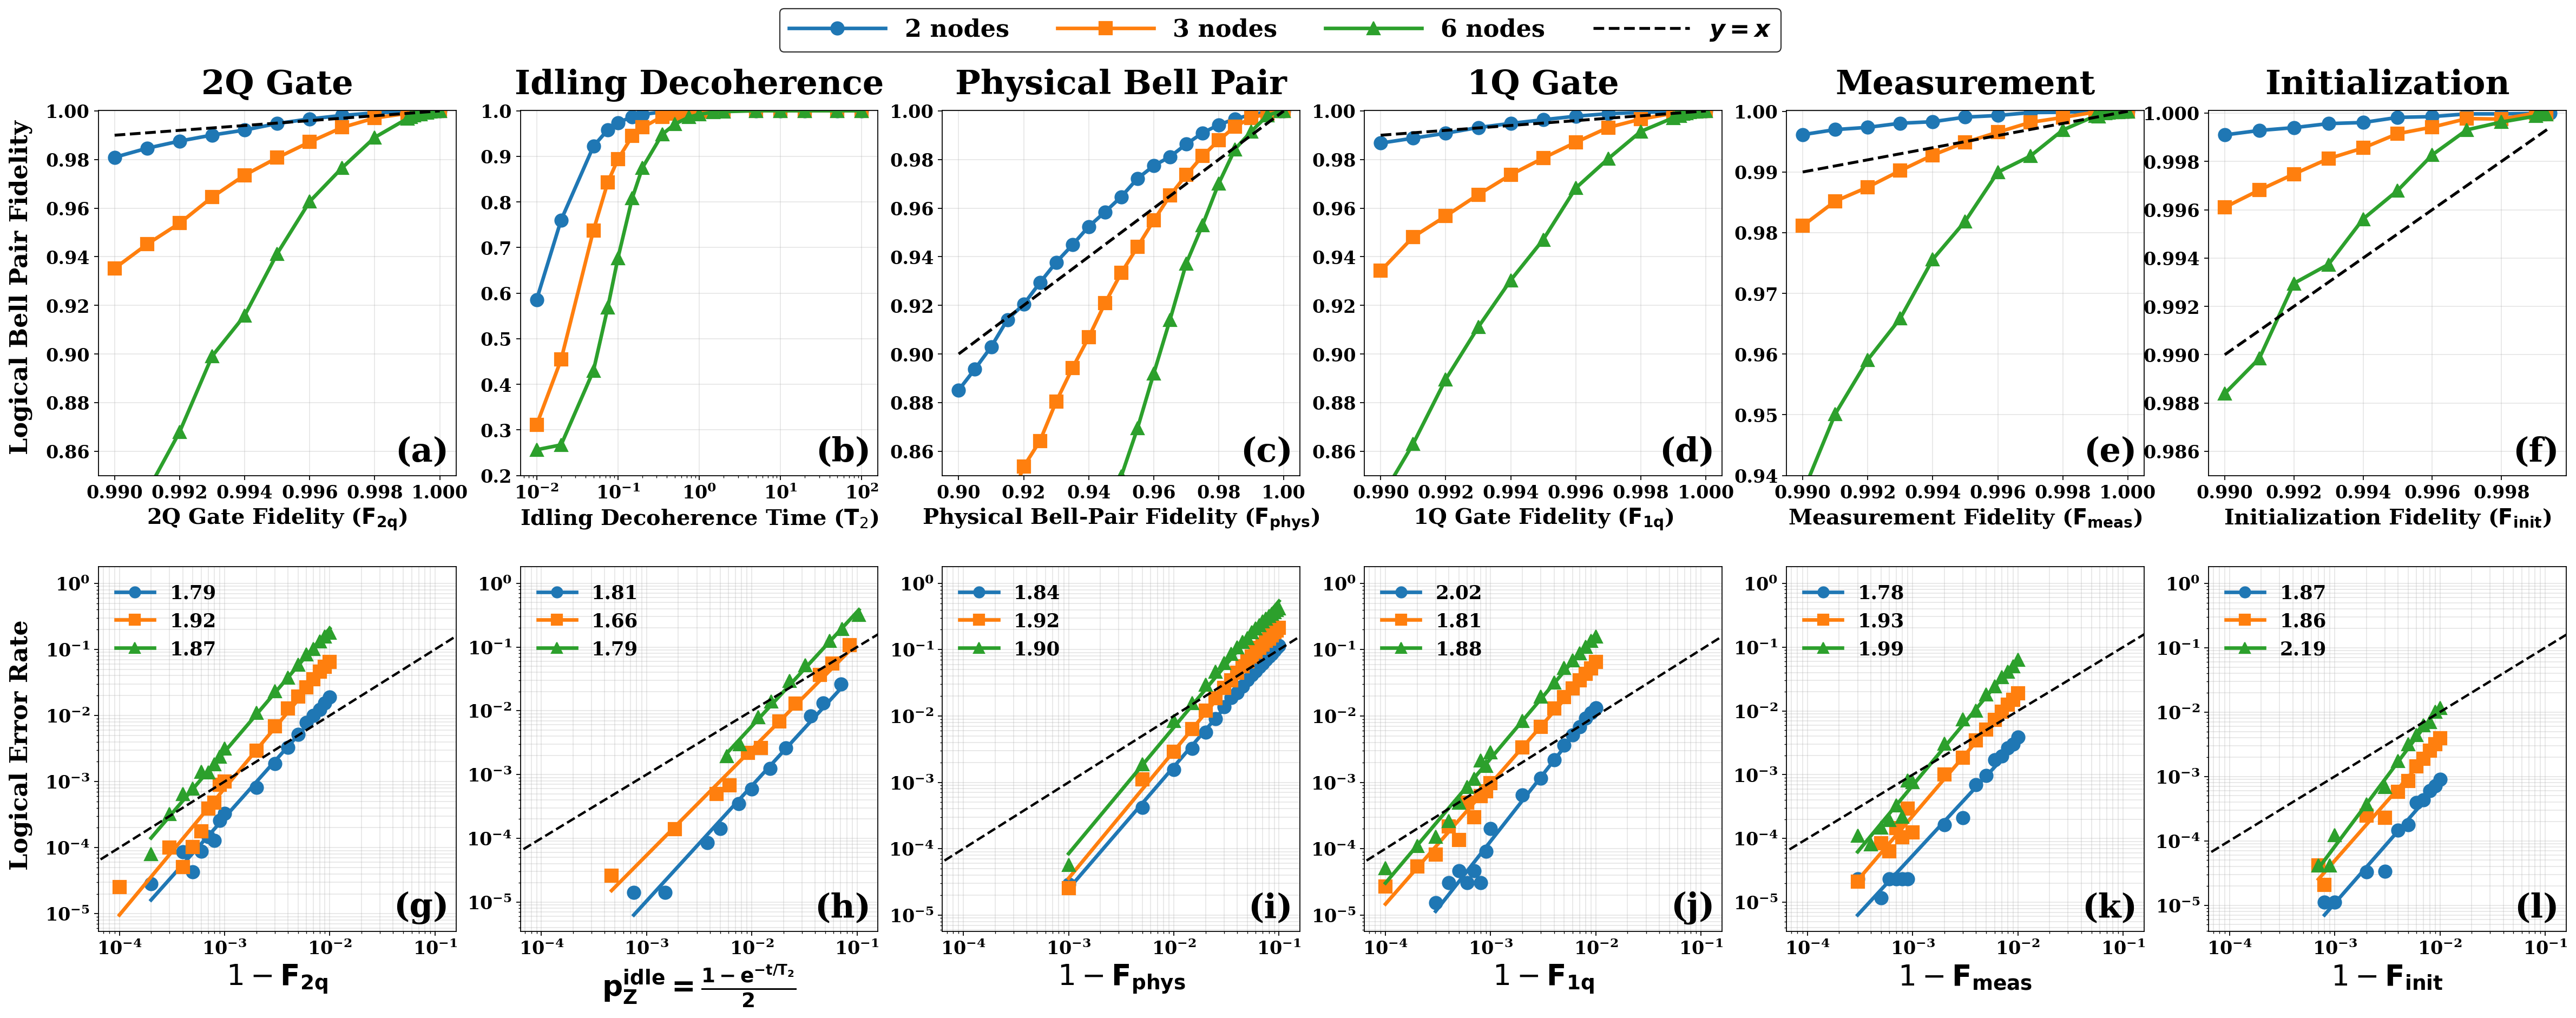

In [182]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(2, 6, figsize=(30,12), constrained_layout=False)
fig.subplots_adjust(left=0.045, right=0.995, top=0.89, bottom=0.10, wspace=0.18, hspace=0.25)
top_title_fontsize = 28
xlabel_fontsize = 18
bottom_xlabel_fontsize = 24
tick_labelsize = 15
bottom_legend_fontsize = 16
top_legend_fontsize = 20
data_linewidth = 3.0
reference_linewidth = 2.4
fit_linewidth = 3.0
bottom_reference_linewidth = 2.0
marker_scale = 1.8
bottom_marker_handles = [
    Line2D([], [], color=node_colors[2], marker=node_markers[2], linestyle="-", linewidth=fit_linewidth, markersize=5 * marker_scale),
    Line2D([], [], color=node_colors[3], marker=node_markers[3], linestyle="-", linewidth=fit_linewidth, markersize=5 * marker_scale),
    Line2D([], [], color=node_colors[6], marker=node_markers[6], linestyle="-", linewidth=fit_linewidth, markersize=5 * marker_scale),
]

for nodes in sorted(twoq_df["nodes"].unique()):
    d = twoq_df[twoq_df["nodes"] == nodes]
    axes[0, 0].plot(d["sweep_value"], d["fidelity_corrected"], color=node_colors[nodes], marker=node_markers[nodes], markersize=6 * marker_scale, linewidth=data_linewidth, label=f"{nodes} nodes")
xline = np.linspace(twoq_df["sweep_value"].min(), twoq_df["sweep_value"].max(), 200)
axes[0, 0].plot(xline, xline, linestyle="--", color="black", linewidth=reference_linewidth, label=r"$\boldsymbol{y=x}$")
axes[0, 0].set_title("2Q Gate", fontsize=top_title_fontsize, pad=14)
axes[0, 0].set_xlabel(r"2Q Gate Fidelity ($\mathbf{F}_{\mathbf{2q}}$)", fontsize=xlabel_fontsize)
axes[0, 0].set_ylim(0.85, 1.0001)
axes[0, 0].grid(True, alpha=0.3)

for nodes in sorted(t2_df["nodes"].unique()):
    d = t2_df[t2_df["nodes"] == nodes]
    axes[0, 1].plot(d["sweep_value"], d["fidelity_corrected"], color=node_colors[nodes], marker=node_markers[nodes], markersize=6 * marker_scale, linewidth=data_linewidth, label=f"{nodes} nodes")
axes[0, 1].set_title("Idling Decoherence", fontsize=top_title_fontsize, pad=14)
axes[0, 1].set_xlabel(r"Idling Decoherence Time ($\mathbf{T}_2$)", fontsize=xlabel_fontsize)
axes[0, 1].set_xscale("log")
axes[0, 1].set_ylim(0.2, 1.0001)
axes[0, 1].grid(True, alpha=0.3)

for nodes in sorted(bell_df["nodes"].unique()):
    d = bell_df[bell_df["nodes"] == nodes]
    axes[0, 2].plot(d["sweep_value"], d["fidelity_corrected"], color=node_colors[nodes], marker=node_markers[nodes], markersize=6 * marker_scale, linewidth=data_linewidth, label=f"{nodes} nodes")
xline = np.linspace(bell_df["sweep_value"].min(), bell_df["sweep_value"].max(), 200)
axes[0, 2].plot(xline, xline, linestyle="--", color="black", linewidth=reference_linewidth, label=r"$\boldsymbol{y=x}$")
axes[0, 2].set_title("Physical Bell Pair", fontsize=top_title_fontsize, pad=14)
axes[0, 2].set_xlabel(r"Physical Bell-Pair Fidelity ($\mathbf{F}_{\mathbf{phys}}$)", fontsize=xlabel_fontsize)
axes[0, 2].set_ylim(0.85, 1.0001)
axes[0, 2].grid(True, alpha=0.3)

for nodes in sorted(oneq_df["nodes"].unique()):
    d = oneq_df[oneq_df["nodes"] == nodes]
    axes[0, 3].plot(d["sweep_value"], d["fidelity_corrected"], color=node_colors[nodes], marker=node_markers[nodes], markersize=6 * marker_scale, linewidth=data_linewidth, label=f"{nodes} nodes")
xline = np.linspace(oneq_df["sweep_value"].min(), oneq_df["sweep_value"].max(), 200)
axes[0, 3].plot(xline, xline, linestyle="--", color="black", linewidth=reference_linewidth, label=r"$\boldsymbol{y=x}$")
axes[0, 3].set_title("1Q Gate", fontsize=top_title_fontsize, pad=14)
axes[0, 3].set_xlabel(r"1Q Gate Fidelity ($\mathbf{F}_{\mathbf{1q}}$)", fontsize=xlabel_fontsize)
axes[0, 3].set_ylim(0.85, 1.0001)
axes[0, 3].grid(True, alpha=0.3)

for nodes in sorted(meas_df["nodes"].unique()):
    d = meas_df[meas_df["nodes"] == nodes]
    axes[0, 4].plot(d["sweep_value"], d["fidelity_corrected"], color=node_colors[nodes], marker=node_markers[nodes], markersize=6 * marker_scale, linewidth=data_linewidth, label=f"{nodes} nodes")
xline = np.linspace(meas_df["sweep_value"].min(), meas_df["sweep_value"].max(), 200)
axes[0, 4].plot(xline, xline, linestyle="--", color="black", linewidth=reference_linewidth, label=r"$\boldsymbol{y=x}$")
axes[0, 4].set_title("Measurement", fontsize=top_title_fontsize, pad=14)
axes[0, 4].set_xlabel(r"Measurement Fidelity ($\mathbf{F}_{\mathbf{meas}}$)", fontsize=xlabel_fontsize)
axes[0, 4].set_ylim(0.94, 1.0001)
axes[0, 4].grid(True, alpha=0.3)

for nodes in sorted(init_df["nodes"].unique()):
    d = init_df[init_df["nodes"] == nodes]
    axes[0, 5].plot(d["sweep_value"], d["fidelity_corrected"], color=node_colors[nodes], marker=node_markers[nodes], markersize=6 * marker_scale, linewidth=data_linewidth, label=f"{nodes} nodes")
xline = np.linspace(init_df["sweep_value"].min(), init_df["sweep_value"].max(), 200)
axes[0, 5].plot(xline, xline, linestyle="--", color="black", linewidth=reference_linewidth, label=r"$\boldsymbol{y=x}$")
axes[0, 5].set_title("Initialization", fontsize=top_title_fontsize, pad=14)
axes[0, 5].set_xlabel(r"Initialization Fidelity ($\mathbf{F}_{\mathbf{init}}$)", fontsize=xlabel_fontsize)
axes[0, 5].set_ylim(0.985, 1.0001)
axes[0, 5].grid(True, alpha=0.3)

for nodes in sorted(twoq_df["nodes"].unique()):
    d = twoq_df[twoq_df["nodes"] == nodes].copy()
    x = 1.0 - d["sweep_value"].to_numpy()
    y = 1.0 - d["fidelity_corrected"].to_numpy()
    mask = (x > 0.0) & (y > 0.0)
    x = x[mask]
    y = y[mask]
    axes[1, 0].plot(x, y, linestyle="", color=node_colors[nodes], marker=node_markers[nodes], markersize=6 * marker_scale)
    if len(x) >= 2:
        coeffs = np.polyfit(np.log10(x), np.log10(y), 1)
        xfit = np.sort(x)
        yfit = 10 ** (coeffs[1] + coeffs[0] * np.log10(xfit))
        axes[1, 0].plot(xfit, yfit, color=node_colors[nodes], linewidth=fit_linewidth, label=f"{coeffs[0]:.2f}")
axes[1, 0].set_xscale("log")
axes[1, 0].set_yscale("log")
axes[1, 0].set_xlim(10 ** -4.2, 10 ** -0.8)
axes[1, 0].plot([1e-5, 1], [1e-5, 1], linestyle="--", color="black", linewidth=bottom_reference_linewidth)
axes[1, 0].set_xlabel(r"$1 - \mathbf{F}_{\mathbf{2q}}$", fontsize=bottom_xlabel_fontsize)
axes[1, 0].grid(True, which="both", alpha=0.3)
axes[1, 0].legend(bottom_marker_handles, axes[1, 0].get_legend_handles_labels()[1], loc="upper left", frameon=False, prop={"size": bottom_legend_fontsize, "weight": "bold"})

t2_fit_min = 0.1

for nodes in sorted(t2_df["nodes"].unique()):
    d = t2_df[(t2_df["nodes"] == nodes) & (t2_df["sweep_value"] >= t2_fit_min)].copy()
    idle_time_sec = d["latency_ps"].to_numpy() * 1e-12
    x = (1.0 - np.exp(-idle_time_sec / d["sweep_value"].to_numpy())) / 2.0
    y = 1.0 - d["fidelity_corrected"].to_numpy()
    mask = (x > 0.0) & (y > 0.0)
    x = x[mask]
    y = y[mask]
    axes[1, 1].plot(x, y, linestyle="", color=node_colors[nodes], marker=node_markers[nodes], markersize=6 * marker_scale)
    if len(x) >= 2:
        coeffs = np.polyfit(np.log10(x), np.log10(y), 1)
        xfit = np.sort(x)
        yfit = 10 ** (coeffs[1] + coeffs[0] * np.log10(xfit))
        axes[1, 1].plot(xfit, yfit, color=node_colors[nodes], linewidth=fit_linewidth, label=f"{coeffs[0]:.2f}")
axes[1, 1].set_xscale("log")
axes[1, 1].set_yscale("log")
axes[1, 1].set_xlim(10 ** -4.2, 10 ** -0.8)
axes[1, 1].plot([1e-5, 1], [1e-5, 1], linestyle="--", color="black", linewidth=bottom_reference_linewidth)
axes[1, 1].set_xlabel(r"$\mathbf{p_Z^{idle} = \frac{1 - e^{-t/T_2}}{2}}$", fontsize=bottom_xlabel_fontsize)
axes[1, 1].grid(True, which="both", alpha=0.3)
axes[1, 1].legend(bottom_marker_handles, axes[1, 1].get_legend_handles_labels()[1], loc="upper left", frameon=False, prop={"size": bottom_legend_fontsize, "weight": "bold"})

for nodes in sorted(bell_df["nodes"].unique()):
    d = bell_df[bell_df["nodes"] == nodes].copy()
    x = 1.0 - d["sweep_value"].to_numpy()
    y = 1.0 - d["fidelity_corrected"].to_numpy()
    mask = (x > 0.0) & (y > 0.0)
    x = x[mask]
    y = y[mask]
    axes[1, 2].plot(x, y, linestyle="", color=node_colors[nodes], marker=node_markers[nodes], markersize=6 * marker_scale)
    if len(x) >= 2:
        coeffs = np.polyfit(np.log10(x), np.log10(y), 1)
        xfit = np.sort(x)
        yfit = 10 ** (coeffs[1] + coeffs[0] * np.log10(xfit))
        axes[1, 2].plot(xfit, yfit, color=node_colors[nodes], linewidth=fit_linewidth, label=f"{coeffs[0]:.2f}")
axes[1, 2].set_xscale("log")
axes[1, 2].set_yscale("log")
axes[1, 2].set_xlim(10 ** -4.2, 10 ** -0.8)
axes[1, 2].plot([1e-5, 1], [1e-5, 1], linestyle="--", color="black", linewidth=bottom_reference_linewidth)
axes[1, 2].set_xlabel(r"$1 - \mathbf{F}_{\mathbf{phys}}$", fontsize=bottom_xlabel_fontsize)
axes[1, 2].grid(True, which="both", alpha=0.3)
axes[1, 2].legend(bottom_marker_handles, axes[1, 2].get_legend_handles_labels()[1], loc="upper left", frameon=False, prop={"size": bottom_legend_fontsize, "weight": "bold"})

for nodes in sorted(oneq_df["nodes"].unique()):
    d = oneq_df[oneq_df["nodes"] == nodes].copy()
    x = 1.0 - d["sweep_value"].to_numpy()
    y = 1.0 - d["fidelity_corrected"].to_numpy()
    mask = (x > 0.0) & (y > 0.0)
    x = x[mask]
    y = y[mask]
    axes[1, 3].plot(x, y, linestyle="", color=node_colors[nodes], marker=node_markers[nodes], markersize=6 * marker_scale)
    if len(x) >= 2:
        coeffs = np.polyfit(np.log10(x), np.log10(y), 1)
        xfit = np.sort(x)
        yfit = 10 ** (coeffs[1] + coeffs[0] * np.log10(xfit))
        axes[1, 3].plot(xfit, yfit, color=node_colors[nodes], linewidth=fit_linewidth, label=f"{coeffs[0]:.2f}")
axes[1, 3].set_xscale("log")
axes[1, 3].set_yscale("log")
axes[1, 3].set_xlim(10 ** -4.2, 10 ** -0.8)
axes[1, 3].plot([1e-5, 1], [1e-5, 1], linestyle="--", color="black", linewidth=bottom_reference_linewidth)
axes[1, 3].set_xlabel(r"$1 - \mathbf{F}_{\mathbf{1q}}$", fontsize=bottom_xlabel_fontsize)
axes[1, 3].grid(True, which="both", alpha=0.3)
axes[1, 3].legend(bottom_marker_handles, axes[1, 3].get_legend_handles_labels()[1], loc="upper left", frameon=False, prop={"size": bottom_legend_fontsize, "weight": "bold"})

for nodes in sorted(meas_df["nodes"].unique()):
    d = meas_df[meas_df["nodes"] == nodes].copy()
    x = 1.0 - d["sweep_value"].to_numpy()
    y = 1.0 - d["fidelity_corrected"].to_numpy()
    mask = (x > 0.0) & (y > 0.0)
    x = x[mask]
    y = y[mask]
    axes[1, 4].plot(x, y, linestyle="", color=node_colors[nodes], marker=node_markers[nodes], markersize=6 * marker_scale)
    if len(x) >= 2:
        coeffs = np.polyfit(np.log10(x), np.log10(y), 1)
        xfit = np.sort(x)
        yfit = 10 ** (coeffs[1] + coeffs[0] * np.log10(xfit))
        axes[1, 4].plot(xfit, yfit, color=node_colors[nodes], linewidth=fit_linewidth, label=f"{coeffs[0]:.2f}")
axes[1, 4].set_xscale("log")
axes[1, 4].set_yscale("log")
axes[1, 4].set_xlim(10 ** -4.2, 10 ** -0.8)
axes[1, 4].plot([1e-5, 1], [1e-5, 1], linestyle="--", color="black", linewidth=bottom_reference_linewidth)
axes[1, 4].set_xlabel(r"$1 - \mathbf{F}_{\mathbf{meas}}$", fontsize=bottom_xlabel_fontsize)
axes[1, 4].grid(True, which="both", alpha=0.3)
axes[1, 4].legend(bottom_marker_handles, axes[1, 4].get_legend_handles_labels()[1], loc="upper left", frameon=False, prop={"size": bottom_legend_fontsize, "weight": "bold"})

for nodes in sorted(init_df["nodes"].unique()):
    d = init_df[init_df["nodes"] == nodes].copy()
    x = 1.0 - d["sweep_value"].to_numpy()
    y = 1.0 - d["fidelity_corrected"].to_numpy()
    mask = (x > 0.0) & (y > 0.0)
    x = x[mask]
    y = y[mask]
    axes[1, 5].plot(x, y, linestyle="", color=node_colors[nodes], marker=node_markers[nodes], markersize=6 * marker_scale)
    if len(x) >= 2:
        coeffs = np.polyfit(np.log10(x), np.log10(y), 1)
        xfit = np.sort(x)
        yfit = 10 ** (coeffs[1] + coeffs[0] * np.log10(xfit))
        axes[1, 5].plot(xfit, yfit, color=node_colors[nodes], linewidth=fit_linewidth, label=f"{coeffs[0]:.2f}")
axes[1, 5].set_xscale("log")
axes[1, 5].set_yscale("log")
axes[1, 5].set_xlim(10 ** -4.2, 10 ** -0.8)
axes[1, 5].plot([1e-5, 1], [1e-5, 1], linestyle="--", color="black", linewidth=bottom_reference_linewidth)
axes[1, 5].set_xlabel(r"$1 - \mathbf{F}_{\mathbf{init}}$", fontsize=bottom_xlabel_fontsize)
axes[1, 5].grid(True, which="both", alpha=0.3)
axes[1, 5].legend(bottom_marker_handles, axes[1, 5].get_legend_handles_labels()[1], loc="upper left", frameon=False, prop={"size": bottom_legend_fontsize, "weight": "bold"})

for axis in axes[0, :]:
    axis.set_ylabel("")
    axis.tick_params(axis="both", labelsize=tick_labelsize)

for axis in axes[1, :]:
    axis.set_ylabel("")
    axis.tick_params(axis="both", labelsize=tick_labelsize)

for axis in axes.flat:
    axis.title.set_fontweight("bold")
    axis.xaxis.label.set_fontweight("bold")
    axis.yaxis.label.set_fontweight("bold")
    for tick_label in axis.get_xticklabels() + axis.get_yticklabels():
        tick_label.set_fontweight("bold")

panel_labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)", "(i)", "(j)", "(k)", "(l)"]
for panel_index, (axis, panel_label) in enumerate(zip(axes.flat, panel_labels)):
    axis.text(
        0.98,
        0.02,
        panel_label,
        transform=axis.transAxes,
        va="bottom",
        ha="right",
        fontsize=top_title_fontsize,
        fontweight="bold",
    )


handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=True, edgecolor="black", facecolor="white", bbox_to_anchor=(0.5, 1), prop={"size": top_legend_fontsize, "weight": "bold"}, handlelength=4.0)

fig.text(0.015, 0.72, "Logical Bell Pair Fidelity", rotation=90, va="center", ha="center", fontsize=20, fontweight="bold")
fig.text(0.015, 0.28, "Logical Error Rate", rotation=90, va="center", ha="center", fontsize=20, fontweight="bold")
fig.savefig("/Users/patange/Documents/Argonne/QEC/plot_pngs/thresholds.png", bbox_inches="tight", pad_inches=0.2)
fig.savefig("/Users/patange/Documents/Argonne/QEC/plot_pngs/thresholds.pdf", bbox_inches="tight", pad_inches=0.2)
plt.show()